---
title: "RAPIDS GPU acceleration"
subtitle: "cuDF and cuML benchmarks. GPU vs CPU comparison."
author: "Author: Ignacio Masari (EODC)"
tags: [RAPIDS, cuDF, cuML, GPU]
thumbnail: ../img/DE_logo.jpg
license: MIT
copyright: "© 2026 EODC GmbH."
---

# RAPIDS GPU Acceleration

RAPIDS provides GPU-native replacements for common pandas and scikit-learn workflows.

| | |
|---|---|
| **Data** | Synthetic arrays and DataFrames |
| **Task** | DataFrame aggregation, classification, clustering |
| **Framework** | cuDF + cuML |
| **Expected runtime** | <1 min on GPU |

In [1]:
import numpy as np, time
from numba import cuda as numba_cuda

# Sanity check — the container's start.sh sets NUMBA_CUDA_DRIVER so numba-cuda
# can find libcuda.so injected by the NVIDIA runtime.
numba_cuda.select_device(0)
print(f"CUDA device : {numba_cuda.get_current_device().name.decode()}")

CUDA device : NVIDIA RTXA6000-24Q


In [2]:
import cudf, cuml
print(f"cuDF  version : {cudf.__version__}")

cuDF  version : 25.04.00


# cuDF — pandas-compatible DataFrames on GPU

We compare a `groupby().mean()` on pandas vs cuDF across several dataset sizes.

n=   100,000  pandas=     4.0 ms  cuDF=    2.9 ms  speedup=  1.4x
n=   500,000  pandas=    11.4 ms  cuDF=    4.8 ms  speedup=  2.4x
n= 2,000,000  pandas=    37.7 ms  cuDF=    4.7 ms  speedup=  8.0x
n=10,000,000  pandas=   190.9 ms  cuDF=   12.8 ms  speedup= 15.0x


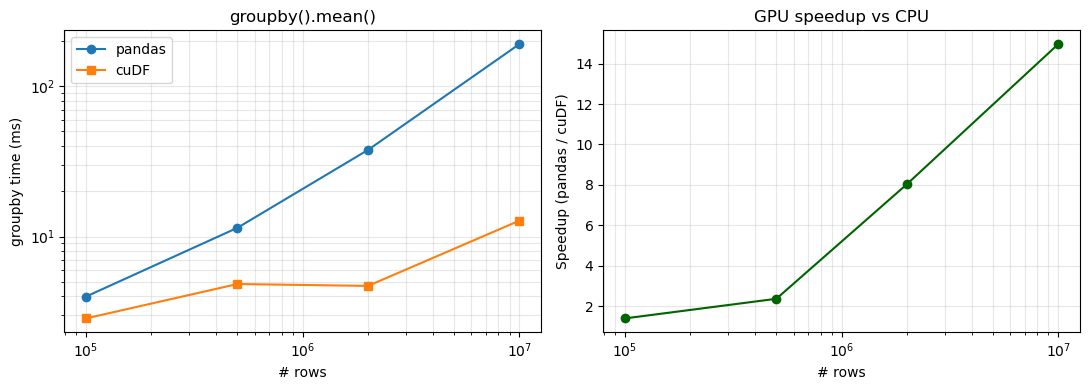

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

sizes = [100_000, 500_000, 2_000_000, 10_000_000]
cpu_t, gpu_t = [], []
for n in sizes:
    data = {
        "x": np.random.randn(n),
        "y": np.random.randn(n),
        "group": np.random.randint(0, 100, n),
    }
    df_pd  = pd.DataFrame(data)
    df_gpu = cudf.DataFrame(data)

    t0 = time.perf_counter()
    _ = df_pd.groupby("group")[["x", "y"]].mean()
    cpu_t.append(time.perf_counter() - t0)

    # warm-up
    _ = df_gpu.groupby("group")[["x", "y"]].mean().to_pandas()
    t0 = time.perf_counter()
    _ = df_gpu.groupby("group")[["x", "y"]].mean().to_pandas()
    gpu_t.append(time.perf_counter() - t0)
    print(f"n={n:>10,d}  pandas={cpu_t[-1]*1000:8.1f} ms  cuDF={gpu_t[-1]*1000:7.1f} ms  speedup={cpu_t[-1]/gpu_t[-1]:5.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(sizes, [t*1000 for t in cpu_t], "o-", label="pandas")
axes[0].loglog(sizes, [t*1000 for t in gpu_t], "s-", label="cuDF")
axes[0].set_xlabel("# rows"); axes[0].set_ylabel("groupby time (ms)")
axes[0].set_title("groupby().mean()"); axes[0].legend(); axes[0].grid(True, which="both", alpha=0.3)
axes[1].semilogx(sizes, [c/g for c, g in zip(cpu_t, gpu_t)], "o-", color="darkgreen")
axes[1].set_xlabel("# rows"); axes[1].set_ylabel("Speedup (pandas / cuDF)")
axes[1].set_title("GPU speedup vs CPU"); axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()